# Analytic formulas for the CHIANTI metal-line cooling tables

Comparison of the hard-coded CHIANTI v11.0.2 cooling tables
(`metal_cooling_chianti.txt`, the source of the `cool_logL_*` arrays in
`Cool_coeff.f90`) against closed-form analytic fits.
Coefficients were obtained by `fit_cooling_formulas.py`.

**Resonance lines** (exact two-level skeleton; only $\Upsilon(T)$ is fitted):

$$\Lambda(T) = \frac{8.629\times10^{-6}}{g_l\,\sqrt{T}}\;
\Upsilon(T)\,\Delta E\;e^{-\Delta E/kT},\qquad
\Upsilon(T) = a + b\,\ln\!\left(1 + T/T_0\right)$$

| channel | $g_l$ | $\Delta E$ [eV] | $a$ | $b$ | $T_0$ [K] | max err |
|---|---|---|---|---|---|---|
| Mg I $\lambda$2853 | 1 | 4.3381 | 0.355792 | 15.1223 | 94126.5 | 2.8% |
| Mg II h&k          | 2 | 4.2766 | 16.2305  | 20.3448 | 121896  | 1.1% |
| Ca II H&K          | 2 | 3.1438 | 14.7415  | 19.492  | 36218.3 | 1.2% |
| Na I D             | 2 | 2.1037 | 36.0744  | 0 (const) | --    | 0.01% |

**Fe II** (sum over hundreds of transitions; 4 effective two-level groups):

$$\Lambda(T) = T^{-1/2}\sum_{i=1}^{4} A_i\,e^{-T_i/T}$$

**Free-free** is already analytic (Huang 2023 Eq. 9):
$\Lambda_{\rm ff} = 1.9095\times10^{-25}\,Z^2\,(T/10^4)^{0.55}$.

*Not covered*: the 2-D density-dependent Fe II table
(`cool_logL_FeII_ne`, a $(T,n_e)$ statistical-equilibrium solve) and the
Fe I table.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

EV_ERG = 1.602176634e-12
K_B    = 1.380649e-16
PREF   = 8.629e-6

tab = np.loadtxt('metal_cooling_chianti.txt', skiprows=10)
T   = tab[:, 0]
NAMES = ['MgI_2853', 'MgII_hk', 'CaII_HK', 'NaI_D',
         'FeII_coronal', 'FeII_boltz']
table = dict(zip(NAMES, tab[:, 1:7].T))
LABELS = {'MgI_2853': r'Mg I $\lambda$2853', 'MgII_hk': r'Mg II h\&k',
          'CaII_HK': r'Ca II H\&K', 'NaI_D': r'Na I D',
          'FeII_coronal': r'Fe II coronal', 'FeII_boltz': r'Fe II Boltzmann'}

In [2]:
# --- fitted formulas (coefficients from fit_cooling_formulas.py) ---

def lam_line(T, g_l, dE_eV, a, b, T0):
    '''Two-level resonance-line cooling with BT type-1 Upsilon(T).'''
    dE  = dE_eV * EV_ERG
    ups = a + b * np.log(1.0 + T / T0)
    return PREF / (g_l * np.sqrt(T)) * ups * dE * np.exp(-dE / (K_B * T))

def lam_multiexp(T, A, Ti):
    '''Sum of effective two-level terms (Fe II).'''
    A, Ti = np.asarray(A), np.asarray(Ti)
    return np.sum(A[:, None] * np.exp(-Ti[:, None] / T[None, :]),
                  axis=0) / np.sqrt(T)

fit = {
  'MgI_2853': lam_line(T, 1.0, 4.3381, 0.355792, 15.1223, 94126.5),
  'MgII_hk' : lam_line(T, 2.0, 4.2766, 16.2305,  20.3448, 121896.0),
  'CaII_HK' : lam_line(T, 2.0, 3.1438, 14.7415,  19.492,  36218.3),
  'NaI_D'   : lam_line(T, 2.0, 2.1037, 36.0744,  0.0,     1.0e30),
  'FeII_coronal': lam_multiexp(T,
        [1.9889e-18, 1.6793e-17, 6.5362e-16, 7.4638e-16],
        [1350.1, 9630.3, 58939.3, 139593.3]),
  'FeII_boltz':   lam_multiexp(T,
        [1.5019e-18, 9.7419e-18, 5.2485e-16, 4.7387e-16],
        [1175.7, 8678.5, 57594.7, 140620.2]),
}

for nm in NAMES:
    rel  = np.abs(fit[nm] / table[nm] - 1.0)
    mask = table[nm] > 1e-3 * table[nm].max()
    print(f'{nm:13s}  max err {rel.max()*100:5.2f}%   '
          f'relevant(T>{T[mask][0]:6.0f}K) {rel[mask].max()*100:5.2f}%   '
          f'rms {np.sqrt(np.mean(rel[mask]**2))*100:5.2f}%')

MgI_2853       max err  2.75%   relevant(T>  7586K)  2.75%   rms  0.99%
MgII_hk        max err  1.06%   relevant(T>  6026K)  1.06%   rms  0.47%
CaII_HK        max err  1.19%   relevant(T>  4677K)  1.19%   rms  0.39%
NaI_D          max err  0.01%   relevant(T>  2818K)  0.00%   rms  0.00%
FeII_coronal   max err  1.61%   relevant(T>  1000K)  1.61%   rms  0.36%
FeII_boltz     max err  1.19%   relevant(T>  1000K)  1.19%   rms  0.33%


## Overview: tables vs formulas (all channels)

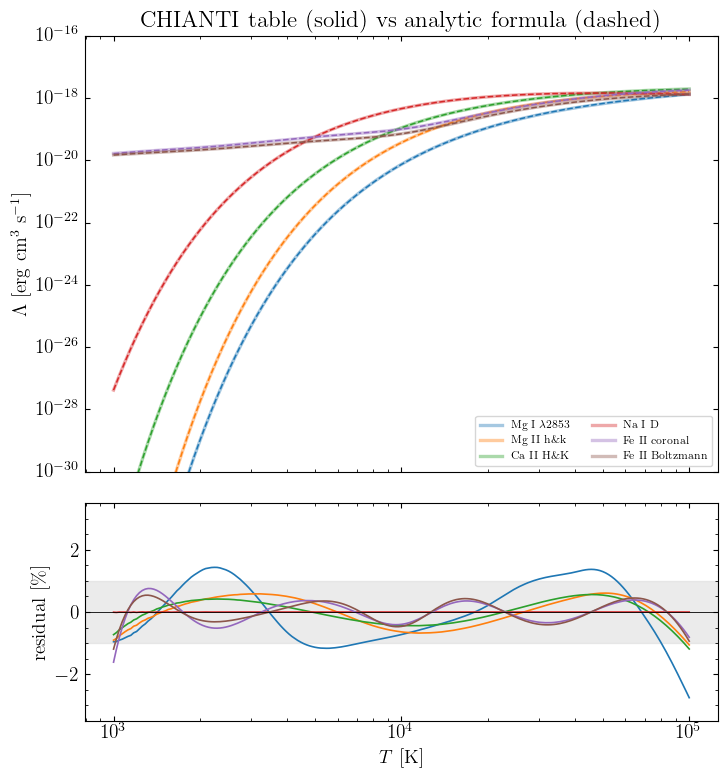

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 8), sharex=True,
                               gridspec_kw=dict(height_ratios=[2, 1]))
for nm in NAMES:
    ln, = ax1.plot(T, table[nm], lw=2.4, alpha=0.4, label=LABELS[nm])
    ax1.plot(T, fit[nm], '--', lw=1.1, color=ln.get_color())
    ax2.plot(T, (fit[nm]/table[nm] - 1.0)*100, lw=1.2, color=ln.get_color())
ax1.set_xscale('log'); ax1.set_yscale('log'); ax1.set_ylim(1e-30, 1e-16)
ax1.set_ylabel(r'$\Lambda$ [erg cm$^3$ s$^{-1}$]')
ax1.legend(fontsize=8, ncol=2, loc='lower right')
ax1.set_title('CHIANTI table (solid) vs analytic formula (dashed)')
ax2.axhline(0, color='k', lw=0.6)
ax2.axhspan(-1, 1, color='0.85', alpha=0.5)
ax2.set_ylim(-3.5, 3.5)
ax2.set_xlabel(r'$T$ [K]')
ax2.set_ylabel(r'residual [\%]')
plt.tight_layout(); plt.show()

## Per-channel comparison with signed residuals

Grey band = $\pm$1%. Vertical dotted line marks where the coolant becomes non-negligible ($\Lambda > 10^{-3}\Lambda_{\rm max}$); to its left $\Lambda$ is so small that the error is irrelevant.

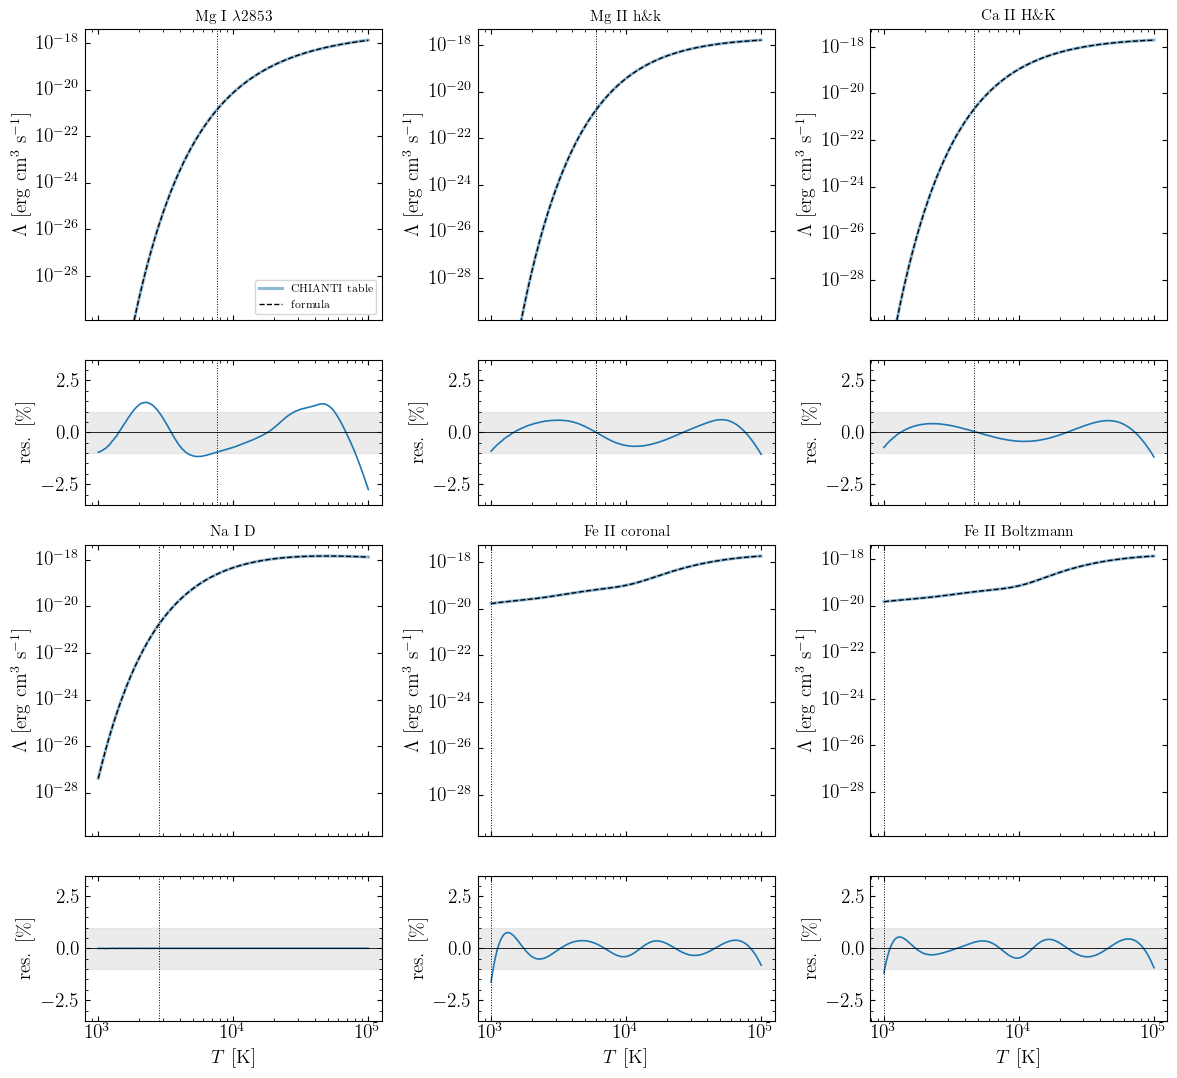

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(12, 11), sharex=True,
                         gridspec_kw=dict(height_ratios=[2, 1, 2, 1]))
pos = [(0, 0), (0, 1), (0, 2), (2, 0), (2, 1), (2, 2)]
for k, nm in enumerate(NAMES):
    r, c = pos[k]
    axc, axr = axes[r, c], axes[r + 1, c]
    mask = table[nm] > 1e-3 * table[nm].max()
    Trel = T[mask][0]
    axc.plot(T, table[nm], lw=2.2, alpha=0.5, label='CHIANTI table')
    axc.plot(T, fit[nm], 'k--', lw=1.0, label='formula')
    axc.set_xscale('log'); axc.set_yscale('log')
    axc.set_ylim(table[nm].max()*1e-12, table[nm].max()*3)
    axc.axvline(Trel, color='k', ls=':', lw=0.7)
    axc.set_title(LABELS[nm], fontsize=11)
    axc.set_ylabel(r'$\Lambda$ [erg cm$^3$ s$^{-1}$]')
    if k == 0:
        axc.legend(fontsize=8, loc='lower right')
    res = (fit[nm]/table[nm] - 1.0)*100
    axr.plot(T, res, lw=1.2)
    axr.axhline(0, color='k', lw=0.6)
    axr.axhspan(-1, 1, color='0.85', alpha=0.5)
    axr.axvline(Trel, color='k', ls=':', lw=0.7)
    axr.set_ylim(-3.5, 3.5)
    axr.set_ylabel(r'res. [\%]')
    if r == 2:
        axr.set_xlabel(r'$T$ [K]')
plt.tight_layout(); plt.show()

## Fe II: contribution of the four effective two-level groups

The fitted $T_i$ map onto physical transition groups: $\sim$0.1 eV (a$^6$D infrared fine structure), $\sim$0.8 eV (optical metastable), $\sim$5 eV (UV resonance), $\sim$12 eV (high-energy tail).

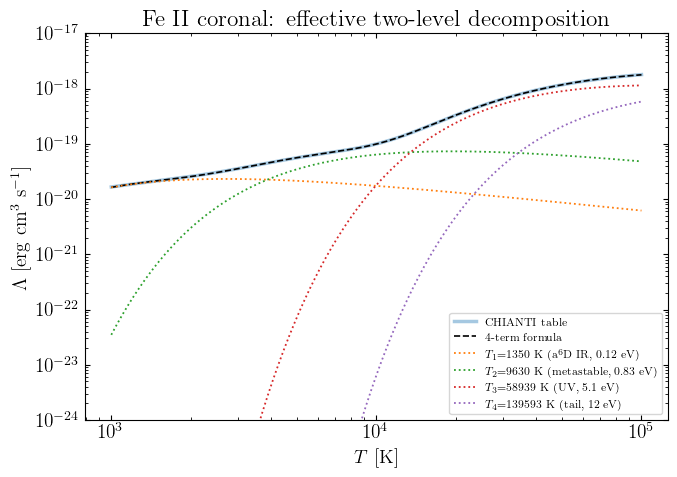

In [5]:
A  = np.array([1.9889e-18, 1.6793e-17, 6.5362e-16, 7.4638e-16])
Ti = np.array([1350.1, 9630.3, 58939.3, 139593.3])
glab = [r'$T_1$=1350 K (a$^6$D IR, 0.12 eV)',
        r'$T_2$=9630 K (metastable, 0.83 eV)',
        r'$T_3$=58939 K (UV, 5.1 eV)',
        r'$T_4$=139593 K (tail, 12 eV)']
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(T, table['FeII_coronal'], lw=2.5, alpha=0.4, label='CHIANTI table')
ax.plot(T, lam_multiexp(T, A, Ti), 'k--', lw=1.2, label='4-term formula')
for i in range(4):
    ax.plot(T, A[i]*np.exp(-Ti[i]/T)/np.sqrt(T), ':', lw=1.3, label=glab[i])
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-24, 1e-17)
ax.set_xlabel(r'$T$ [K]'); ax.set_ylabel(r'$\Lambda$ [erg cm$^3$ s$^{-1}$]')
ax.set_title('Fe II coronal: effective two-level decomposition')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()